# Figure. 8

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd
import scipy
import xrft as xt

In [8]:
ds1 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Data_Scripts/data/Hplus_ssp585_biascorrected.nc')
ds2 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Data_Scripts/data/Hplus_ssp245_biascorrected.nc')
ds3 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Data_Scripts/data/Hplus_ssp126_biascorrected.nc')


In [9]:
lat_range = slice(-30, 30)
lon_range = slice(30, 120)
month_hist  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014'))
month_FF_585  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100'))
month_FF_245  = ds2.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100'))
month_FF_126  = ds3.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100'))


In [10]:


def calculate_ToE(ds, var='Hplus', time_dim='month', k=3):
    """
    Calculate Time of Emergence (ToE) for Hplus data.
    """

    # ---- Ensure DataArray ----
    if isinstance(ds, xr.Dataset):
        Hplus = ds[var]
    else:
        Hplus = ds

    # ---- Trend ----
    def _slope(y):
        t = np.arange(len(y))
        mask = np.isfinite(y)
        if mask.sum() < 2:
            return np.nan
        return linregress(t[mask], y[mask]).slope * 12

    slope = xr.apply_ufunc(
        _slope,
        Hplus,
        input_core_dims=[[time_dim]],
        vectorize=True,
        output_dtypes=[float]
    )

    # ---- Noise (detrended std) ----
    valid_mask = Hplus.isel({time_dim: 0}).notnull()
    Hplus_filled = Hplus.fillna(0)

    detrended = xt.detrend(
        Hplus_filled,
        dim=time_dim,
        detrend_type='linear'
    )

    noise = detrended.where(valid_mask).std(dim=time_dim)

    # ---- ToE ----
    toe = k * noise / abs(slope)

    return toe


In [11]:
#ToE for historical period
Toe_hist = calculate_ToE(
    month_hist,   
    var='Hplus',
    time_dim='time',
    k=3
)

/home/athira/miniconda3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [13]:
#ToE for FF period under SSP5-8.5
Toe_585 = calculate_ToE(
    month_FF_585,   
    var='Hplus',
    time_dim='time',
    k=3
)

/home/athira/miniconda3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [14]:
#ToE for FF period under SSP2-4.5
Toe_245 = calculate_ToE(
    month_FF_245,  
    var='Hplus',
    time_dim='time',
    k=3
)

/home/athira/miniconda3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [15]:
#ToE for FF period under SSP1-2.6
Toe_126 = calculate_ToE(
    month_FF_126,   
    var='Hplus',
    time_dim='time',
    k=3
)

/home/athira/miniconda3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


# ToE Plot

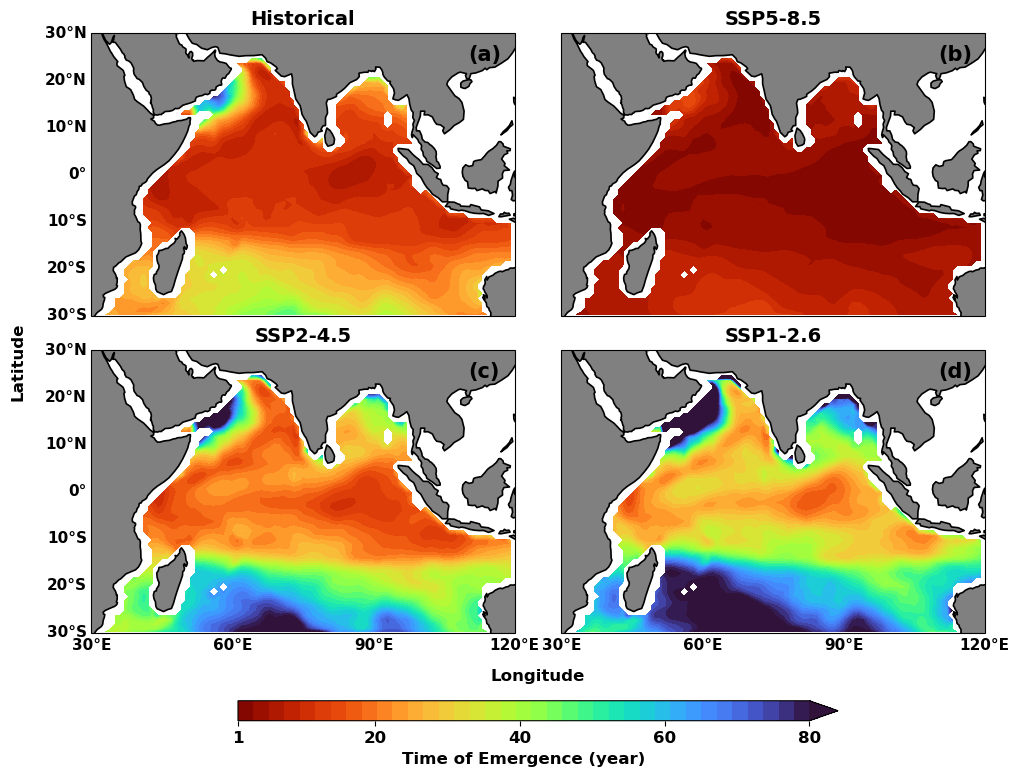

In [16]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.basemap import Basemap

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13

# Colorbar limits
vmin = 1
vmax = 80
levels = np.linspace(vmin, vmax, 38)

#subplot labels
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

#Create figure and axes
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
    subplot_kw={'projection': ccrs.PlateCarree()}
)

plt.subplots_adjust(bottom=0.20, top=0.95, left=0.1, right=0.9,
                    wspace=-0.04, hspace=0.12)

#Titles and data
titles = [
    "Historical",
    "SSP5-8.5",
    "SSP2-4.5",
    "SSP1-2.6"
]

data_list = [
    Toe_hist,
    Toe_585,
    Toe_245,
    Toe_126
]

#Loop over subplots
for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, titles)):

    row, col = divmod(i, 2)

    lon = data.lon
    lat = data.lat

    #Contour plot
    im = ax.contourf(
        lon, lat, data,
        levels=levels,
        cmap='turbo_r',
        vmin=vmin,
        vmax=vmax,
        extend='max',
        transform=ccrs.PlateCarree()
    )

    #Land mask & coastlines
    ax.add_feature(cfeature.LAND, facecolor='gray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=3)

    #Basemap for grid labels
    m = Basemap(
        llcrnrlat=-30.1, urcrnrlat=30.1,
        llcrnrlon=30, urcrnrlon=120.1,
        resolution='c',
        ax=ax
    )

    if col == 0:
        m.drawparallels(
            range(-90, 120, 10),
            labels=[1,0,0,1],
            linewidth=0.001,
            dashes=[4,2],
            color='w',
            fontsize=11
        )

    if row == 1:
        m.drawmeridians(
            range(30,121,30),
            labels=[1,0,0,1],
            linewidth=0.001,
            color='w',
            fontsize=11
        )

    # ---- Subplot labels (a,b,c,d) ----
    ax.text(
        0.89, 0.96, subplot_labels[i],
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top',
        ha='left',
        color='black'
    )

    #Title
    ax.set_title(title, fontsize=14, fontweight='bold')

    #Tick labels
    ax.tick_params(axis='both', labelsize=13)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')

#Common horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.09, 0.50, 0.025])

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation='horizontal',
    extend='max'
)

#Colorbar ticks
cbar.set_ticks([1, 20, 40, 60, 80])

cbar.set_label("Time of Emergence (year)", fontsize=12, fontweight='bold')

cbar.ax.tick_params(labelsize=12)
for tick in cbar.ax.get_xticklabels():
    tick.set_fontweight('bold')

#Common axis labels
fig.text(0.50, 0.14, "Longitude",
         ha="center",
         fontsize=12,
         fontweight="bold")

fig.text(0.060, 0.54, "Latitude",
         va="center",
         rotation="vertical",
         fontsize=12,
         fontweight="bold")

# plt.savefig('ToE_bc_review_f02.jpg', format='jpg', dpi=500)

plt.show()